## Visualization of cleaned data about food delivery app Swiggy

1. Imported required libraries for visualization 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns 

1. Reading Cleaned file

In [2]:
data = pd.read_csv(r"..\data\processed\swiggy_cleaned.csv")

#### What can be the insights possible with the given dataset?!

In [3]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 148541 entries, 0 to 148540
Data columns (total 7 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            148541 non-null  int64  
 1   name          148455 non-null  str    
 2   city          148541 non-null  str    
 3   rating        148541 non-null  float64
 4   rating_count  148541 non-null  float64
 5   cost          148541 non-null  int64  
 6   cuisine       148442 non-null  str    
dtypes: float64(2), int64(2), str(3)
memory usage: 7.9 MB


Possible insights can be :- \
    1. Number of rated and non rated restros \
    2. Top 50 highly rated restros \
    3. No. of restros as per the budget


#### Here we will visualize the data about rated and non rated restros

In [4]:
# To find number of rated restos
rated_restro=data[data['rating'] > 0]['rating'].count()
non_rated_restro=data[data['rating'] == 0]['rating'].count()
print(f'Number of rated restros are:- {rated_restro}')
print(f'Number of non-rated restros are:- {non_rated_restro}')

Number of rated restros are:- 61441
Number of non-rated restros are:- 87100


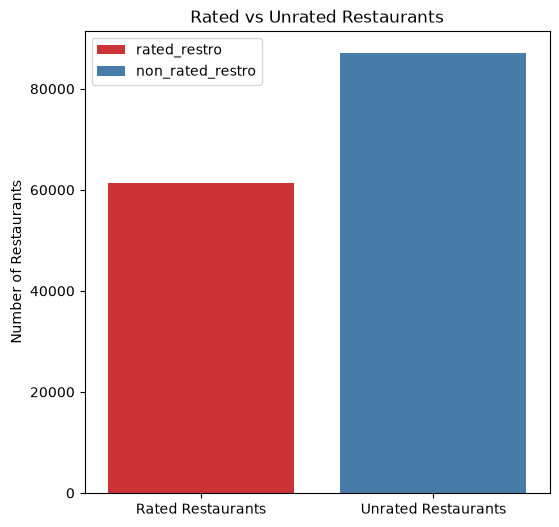

In [18]:
plt.figure(figsize=(6, 6))
sns.barplot(x=['Rated Restaurants', 'Unrated Restaurants'], y=[rated_restro, non_rated_restro],palette='Set1',hue=('rated_restro','non_rated_restro'))
plt.title('Rated vs Unrated Restaurants')
plt.ylabel('Number of Restaurants')
# To save the plot image to the device we will use the following command
plt.savefig(r'..\images/Rated_vs_nonrated.png', bbox_inches='tight', dpi=300)
plt.show()

#### Now lets find top rated 50 restros

In [6]:
# Selects the top 50 rows based on cost, then displays just the name and cost columns
top_50_names = data.nlargest(50, 'rating')[['name', 'rating']]
display(top_50_names)

,name,rating
752,Pablo Premium Kitchen,5.0
1014,The best diet corner,5.0
9688,Creams and Bites,5.0
9736,Bansal's Thali & Combo Meals,5.0
10160,GOWHEY- HEALTHY DESSERT COMPANY,5.0
10607,JUST CREAMERY - Artisanal Healthy Ice Cream,5.0
11091,The Chinese Connection,5.0
11799,HRX by Eatfit,5.0
12046,HUNGER TREATS,5.0
12070,Snack Ride,5.0


C:\Users\Devang Rohilla\AppData\Local\Temp\ipykernel_26428\3738822516.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_50_names, x='rating', y='name', palette='crest')


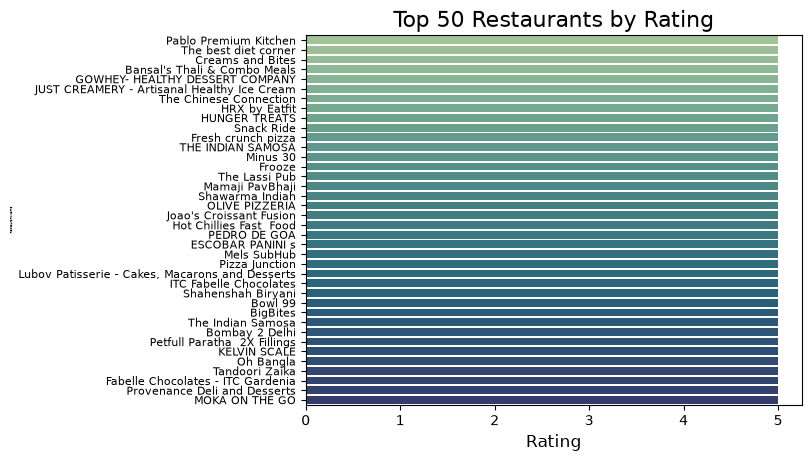

In [19]:
plt.Figure(figsize=(100,200))
sns.barplot(data=top_50_names, x='rating', y='name', palette='crest')

plt.title('Top 50 Restaurants by Rating', fontsize=16)
plt.xlabel('Rating', fontsize=12)
plt.ylabel('Restaurant Name', fontsize=2)
plt.yticks(fontsize=8)
plt.savefig(r'..\images/Top50restros.png', bbox_inches='tight', dpi=300)
plt.show()


#### Lets find number of restro abouve avg budget and lower the avg budget.

In [ ]:
# For avg budget we will,
print(data['cost'].max())
print(data['cost'].idxmax())
avg_budget_mean = data['cost'].mean()
print(avg_budget_mean)

200012000210003281
4966
176392861444171.72


As we can see avg value per restro is much higher then expected that means data contain outliers or extreme points so instead of calculating mean we will try visualizing dataset into intervals using barplot.

C:\Users\Devang Rohilla\AppData\Local\Temp\ipykernel_26428\731027258.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cost_counts.index, y=cost_counts.values, palette='magma')


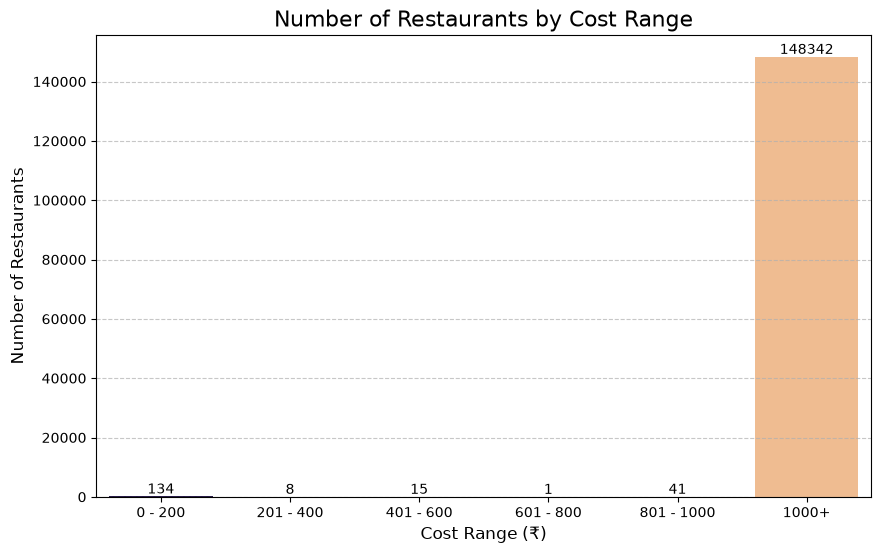

In [20]:
bins = [0, 200, 400, 600, 800, 1000, data['cost'].max()]
labels = ['0 - 200', '201 - 400', '401 - 600', '601 - 800', '801 - 1000', '1000+']

# 3. Create a new column that assigns every row to one of the buckets
data['cost_range'] = pd.cut(data['cost'], bins=bins, labels=labels, right=True)

# 4. Count how many restaurants exist in each bucket and keep the order intact
cost_counts = data['cost_range'].value_counts().reindex(labels)

plt.figure(figsize=(10, 6))
sns.barplot(x=cost_counts.index, y=cost_counts.values, palette='magma')

plt.title('Number of Restaurants by Cost Range', fontsize=16)
plt.xlabel('Cost Range (₹)', fontsize=12)
plt.ylabel('Number of Restaurants', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of the bars for exact counts
for index, value in enumerate(cost_counts.values):
    plt.text(index, value + 1000, str(value), ha='center', fontsize=10)
plt.savefig(r'..\images/cost_range_bar.png', bbox_inches='tight', dpi=300)
plt.show()